# Problème 2 — PageRank : Puissance itérée vs Marche aléatoire

On étudie l'algorithme PageRank sur un graphe aléatoire de type Erdős–Rényi.
On compare deux méthodes d'estimation du vecteur stationnaire $\pi$ :

1. **Puissance itérée** : on multiplie itérativement le vecteur par la matrice de transition.
2. **Marche aléatoire** : on simule une trajectoire et on estime $\pi$ par les fréquences de passage.

On s'intéresse ensuite à la comparaison des **classements** (rankings) obtenus par les deux méthodes,
à l'aide de plusieurs métriques : Spearman, Kendall, Precision@k, et des versions **pondérées** qui
privilégient les sommets en tête de classement.

## 1. Imports et paramètres

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as scs

In [2]:
n = 1000   # dimension du graphe
p = 0.01   # probabilité d'arête entre deux sommets
alpha = 0.85  # paramètre de téléportation du PageRank
np.random.seed(2)

## 2. Construction du graphe et matrice de transition PageRank

On génère un graphe orienté aléatoire $G(n, p)$ : chaque arête $(i, j)$ avec $i \neq j$ existe avec probabilité $p$.

La matrice de transition PageRank est définie par :
$$P = \alpha \, G + (1 - \alpha) \, \Delta$$

Où :
- $G_{ij} = A_{ij} / \sum_k A_{ik}$ si le sommet $i$ a au moins un voisin sortant, sinon $G_{ij} = \Delta_{ij}$
- $\Delta_{ij} = \frac{1}{n-1}$ pour $i \neq j$, $0$ sinon (matrice de téléportation uniforme)
- $\alpha = 0.85$ : probabilité de suivre un lien plutôt que de téléporter

In [3]:
# Matrice d'adjacence aléatoire (sans boucles)
A = (np.random.rand(n, n) < p).astype(float)
np.fill_diagonal(A, 0)

row_sums = A.sum(axis=1, keepdims=True)

# Matrice de téléportation uniforme
Delta = (np.ones((n, n)) - np.eye(n)) / (n - 1)

# Matrice de navigation : normalisation des lignes, avec gestion des nœuds puits
G = np.zeros((n, n))
nonzero = (row_sums[:, 0] > 0)
G[nonzero] = A[nonzero] / row_sums[nonzero]
G[~nonzero] = Delta[~nonzero]  # nœuds sans lien sortant → téléportation

# Matrice de transition PageRank
P = alpha * G + (1 - alpha) * Delta

print(f"Graphe : {n} sommets, {int(A.sum())} arêtes")
print(f"Nœuds sans lien sortant : {(~nonzero).sum()}")
print(f"Vérification stochastique : lignes somment à {P.sum(axis=1).min():.6f} — {P.sum(axis=1).max():.6f}")

Graphe : 1000 sommets, 10128 arêtes
Nœuds sans lien sortant : 0
Vérification stochastique : lignes somment à 1.000000 — 1.000000


## 3. Calcul du PageRank par puissance itérée

On calcule le vecteur stationnaire $\pi$ tel que $\pi = P^T \pi$ par itérations successives.
La convergence est géométrique avec un taux $\alpha = 0.85$, soit environ $\log(\alpha) \approx -0.163$ par itération en échelle log.

In [4]:
pi = np.ones(n) / n
distances_cv = []
i = 0

while True:
    pi_new = P.T @ pi
    d = np.linalg.norm(pi_new - pi, ord=1)
    distances_cv.append(d)
    i += 1
    if d < 1e-9:
        break
    pi = pi_new

pi_m = pi_new  # vecteur stationnaire par puissance itérée
print(f"Convergence en {i} itérations (distance L1 finale : {distances_cv[-1]:.2e})")

Convergence en 17 itérations (distance L1 finale : 2.97e-10)


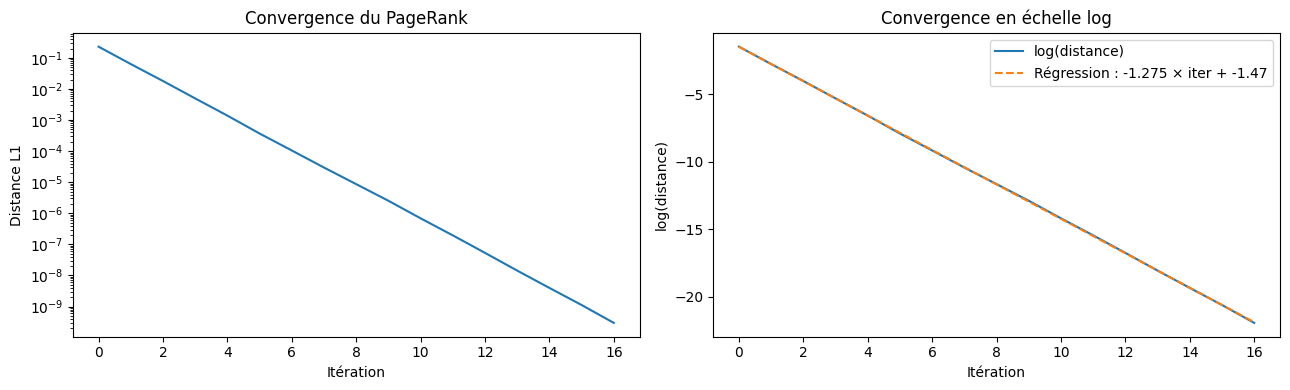

Taux de convergence empirique : -1.2754 (théorique : log(alpha) = -0.1625)


In [5]:
# Convergence en échelle log + régression linéaire
from sklearn.linear_model import LinearRegression

log_dist = np.log(distances_cv)
X_iter = np.arange(len(distances_cv)).reshape(-1, 1)
reg = LinearRegression().fit(X_iter, log_dist)
a, b = reg.coef_[0], reg.intercept_

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(distances_cv)
axes[0].set_yscale('log')
axes[0].set_xlabel('Itération')
axes[0].set_ylabel('Distance L1')
axes[0].set_title('Convergence du PageRank')

axes[1].plot(X_iter, log_dist, label='log(distance)')
axes[1].plot(X_iter, a * X_iter + b, '--', label=f'Régression : {a:.3f} × iter + {b:.2f}')
axes[1].set_xlabel('Itération')
axes[1].set_ylabel('log(distance)')
axes[1].set_title('Convergence en échelle log')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Taux de convergence empirique : {a:.4f} (théorique : log(alpha) = {np.log(alpha):.4f})")

## 4. Estimation par marche aléatoire

On simule une marche aléatoire sur le graphe selon la matrice $P$.
Pour chaque nombre de pas $T = 10^k$, on estime $\pi$ par les fréquences empiriques de passage :
$$\hat{\pi}_i = \frac{\text{nombre de visites du sommet } i}{T}$$

On utilise la CDF cumulée et `np.searchsorted` pour simuler efficacement chaque pas.

In [6]:
pi_s = {}  # dictionnaire : k → estimation pi avec 10^k pas
cdf = np.cumsum(P, axis=1)
cdf[:, -1] = 1.0  # sécurité numérique

for k in range(3, 8):
    np.random.seed(3)
    nb_pas = 10**k
    position = np.random.randint(n)
    count_passages = np.zeros(n)
    count_passages[position] += 1

    for i in range(nb_pas - 1):
        u = np.random.rand()
        position = np.searchsorted(cdf[position], u)
        count_passages[position] += 1

    pi_s[k] = count_passages / nb_pas
    print(f"10^{k} pas : erreur moyenne |pi_s - pi_m| = {np.mean(np.abs(pi_s[k] - pi_m)):.6f}")

10^3 pas : erreur moyenne |pi_s - pi_m| = 0.000801
10^4 pas : erreur moyenne |pi_s - pi_m| = 0.000252
10^5 pas : erreur moyenne |pi_s - pi_m| = 0.000079
10^6 pas : erreur moyenne |pi_s - pi_m| = 0.000025
10^7 pas : erreur moyenne |pi_s - pi_m| = 0.000008


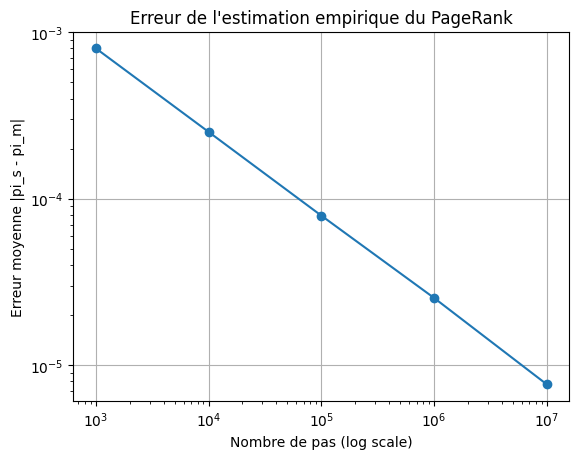

In [7]:
plt.plot([10**k for k in range(3, 8)], [np.mean(np.abs(pi_s[k] - pi_m)) for k in range(3, 8)], marker='o')
plt.yscale('log')
plt.xscale('log')

plt.xlabel('Nombre de pas (log scale)')
plt.ylabel('Erreur moyenne |pi_s - pi_m|')
plt.title('Erreur de l\'estimation empirique du PageRank')
plt.grid(True)
plt.show()

Taux de convergence empirique de l'erreur : -1.1591


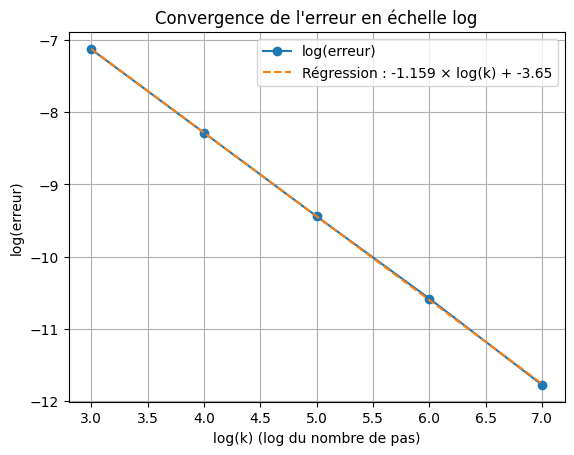

In [8]:
# On fait une régression linéaire sur les points (log(10^k), log(erreur)) pour estimer le taux de convergence empirique
log_k = np.array([k for k in range(3, 8)])
log_erreur = np.log([np.mean(np.abs(pi_s[k] - pi_m)) for k in range(3, 8)])
reg_erreur = LinearRegression().fit(log_k.reshape(-1, 1), log_erreur)
a_erreur, b_erreur = reg_erreur.coef_[0], reg_erreur.intercept_
print(f"Taux de convergence empirique de l'erreur : {a_erreur:.4f}")
# plot :
plt.plot(log_k, log_erreur, marker='o', label='log(erreur)')
plt.plot(log_k, a_erreur * log_k + b_erreur, '--', label=f'Régression : {a_erreur:.3f} × log(k) + {b_erreur:.2f}')
plt.xlabel('log(k) (log du nombre de pas)')
plt.ylabel('log(erreur)')
plt.title('Convergence de l\'erreur en échelle log')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
a_erreur/np.log(10)  # taux de convergence empirique de l'erreur en fonction du nombre de pas 

np.float64(-0.5033762785255855)

### Distribution des erreurs par composante

Pour chaque nombre de pas, on visualise la distribution de $\hat{\pi}_i - \pi_i$ sur tous les sommets.

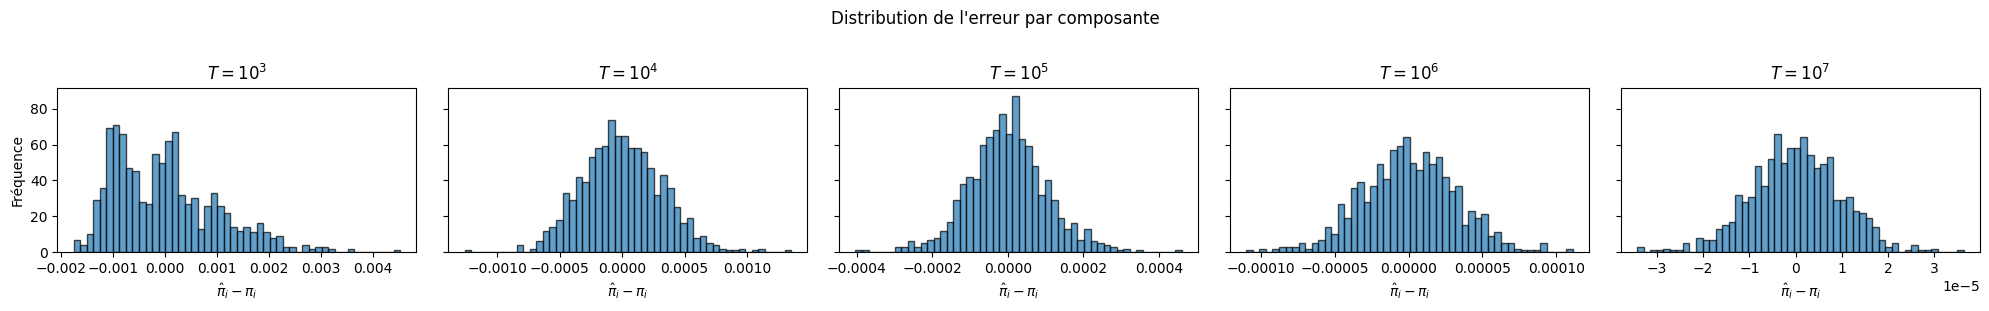

In [10]:
fig, axes = plt.subplots(1, len(pi_s), figsize=(4 * len(pi_s), 3), sharey=True)
for ax, (k, pi_k) in zip(axes, pi_s.items()):
    ax.hist(pi_k - pi_m, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f'$T = 10^{k}$')
    ax.set_xlabel('$\\hat{{\\pi}}_i - \\pi_i$')
axes[0].set_ylabel('Fréquence')
plt.suptitle("Distribution de l'erreur par composante", y=1.02)
plt.tight_layout()
plt.show()

## 5. Construction des classements

On construit les permutations de classement (du sommet le plus important au moins important) :
- $\sigma_m$ : classement par puissance itérée (référence)
- $\sigma_s^{(k)}$ : classement par marche aléatoire avec $10^k$ pas

In [11]:
# sigma[i] = indice du sommet classé i-ème (du plus important au moins important)
sigma_m = np.flip(np.argsort(pi_m))
sigma_s = {k: np.flip(np.argsort(pi_k)) for k, pi_k in pi_s.items()}

# Aperçu des 10 premiers sommets de chaque classement
df = pd.DataFrame({"Puissance itérée": sigma_m, **{f"Marche 10^{k}": s for k, s in sigma_s.items()}})
df.head(10)

,Puissance itérée,Marche 10^3,Marche 10^4,Marche 10^5,Marche 10^6,Marche 10^7
0,464,84,555,70,439,464
1,439,652,915,464,209,439
2,209,147,465,920,464,209
3,993,993,285,915,70,993
4,70,366,859,899,993,70
5,332,17,525,439,915,332
6,915,198,250,492,332,915
7,555,226,899,465,555,555
8,225,646,147,555,241,225
9,241,451,973,993,153,920


---

# Partie II — Métriques de comparaison de classements

On dispose de deux classements $\sigma_1$ (référence) et $\sigma_2$ (estimation), et on veut mesurer à quel point ils se ressemblent. On explore plusieurs approches, avec leurs forces et limites.

## 6. Distance de Spearman (footrule)

La **distance de Spearman** (ou *Spearman footrule*) mesure la somme des déplacements absolus de chaque élément entre les deux classements :
$$d_S(\sigma_1, \sigma_2) = \sum_{i=1}^{n} |r_1(i) - r_2(i)|$$

Où $r_k(i)$ est le **rang** du sommet $i$ dans le classement $\sigma_k$.

### Normalisation
La distance maximale est atteinte quand les deux classements sont inversés :
$$d_S^{\max} = \lfloor n^2 / 2 \rfloor$$

On normalise donc par $\lfloor n^2 / 2 \rfloor$ pour obtenir une distance dans $[0, 1]$ :
- $0$ = classements identiques
- $1$ = classements inversés

In [12]:
def spearman_distance(sigma1, sigma2):
    """Distance de Spearman normalisée entre deux permutations.
    
    sigma[i] = indice du sommet classé en position i.
    Retourne une valeur dans [0, 1].
    """
    n = len(sigma1)
    # rang de chaque sommet
    rank1 = np.argsort(sigma1)  # rank1[v] = position du sommet v dans sigma1
    rank2 = np.argsort(sigma2)
    distance = np.abs(rank1 - rank2).sum()
    return distance / (n**2 // 2)

# Vérification sur un petit exemple
print("Classements identiques :", spearman_distance(np.arange(6), np.arange(6)))
print("Classements inversés  :", spearman_distance(np.arange(6), np.arange(5, -1, -1)))

Classements identiques : 0.0
Classements inversés  : 1.0


In [13]:
# Application aux classements PageRank
spearman_dis = {}
for k, sigma_k in sigma_s.items():
    spearman_dis[k] = spearman_distance(sigma_m, sigma_k)

print("Distance de Spearman entre puissance itérée et marche aléatoire :")
for k, d in spearman_dis.items():
    print(f"  T = 10^{k} : d_S = {d:.6f}")

Distance de Spearman entre puissance itérée et marche aléatoire :
  T = 10^3 : d_S = 0.574416
  T = 10^4 : d_S = 0.377072
  T = 10^5 : d_S = 0.146388
  T = 10^6 : d_S = 0.048920
  T = 10^7 : d_S = 0.015668


**Interprétation** : La distance de Spearman traite tous les sommets de manière égale. Un sommet en position 999 qui se retrouve en position 998 pèse autant qu'un sommet en position 1 qui passe en position 2. Or, en pratique, on se soucie beaucoup plus de la précision du classement **en tête** (les pages les plus importantes).

## 7. Distance de Kendall (tau)

La **distance de Kendall** compte le nombre de **paires discordantes** : des paires $(a, b)$ telles que l'ordre relatif de $a$ et $b$ diffère entre les deux classements.

$$\tau(\sigma_1, \sigma_2) = \frac{\text{concordantes} - \text{discordantes}}{\binom{n}{2}}$$

### Normalisation
Le coefficient $\tau \in [-1, 1]$, on le transforme en distance $d_K = (1 - \tau) / 2 \in [0, 1]$ :
- $0$ = classements identiques (toutes les paires concordantes)
- $1$ = classements parfaitement inversés (toutes les paires discordantes)

In [14]:
def kendall_distance(sigma1, sigma2):
    """Distance de Kendall normalisée entre deux permutations.
    
    Utilise scipy pour un calcul en O(n log n).
    Retourne une valeur dans [0, 1].
    """
    n = len(sigma1)
    rank1 = np.empty(n, dtype=int)
    rank2 = np.empty(n, dtype=int)
    rank1[sigma1] = np.arange(n)
    rank2[sigma2] = np.arange(n)
    # scipy.stats.kendalltau retourne (tau, p-value)
    tau, _ = scs.kendalltau(rank1, rank2)
    return (1 - tau) / 2  # distance dans [0, 1]

In [15]:
# Application aux classements PageRank
kendall_dis = {}
for k, sigma_k in sigma_s.items():
    kendall_dis[k] = kendall_distance(sigma_m, sigma_k)

print("Distance de Kendall entre puissance itérée et marche aléatoire :")
for k, d in kendall_dis.items():
    print(f"  T = 10^{k} : d_K = {d:.6f}")

Distance de Kendall entre puissance itérée et marche aléatoire :
  T = 10^3 : d_K = 0.422166
  T = 10^4 : d_K = 0.269263
  T = 10^5 : d_K = 0.104418
  T = 10^6 : d_K = 0.034270
  T = 10^7 : d_K = 0.010559


**Interprétation** : La distance de Kendall capture les inversions d'ordre entre paires. Comme Spearman, elle traite toutes les paires de manière uniforme : une inversion entre les sommets classés 1er et 2ème compte autant qu'une inversion entre les sommets 999ème et 1000ème.

In [16]:
# Tableau comparatif Spearman vs Kendall
df_classique = pd.DataFrame({
    "T (pas)": [f"$10^{k}$" for k in spearman_dis.keys()],
    "Spearman": [f"{d:.6f}" for d in spearman_dis.values()],
    "Kendall": [f"{d:.6f}" for d in kendall_dis.values()],
})
df_classique

,T (pas),Spearman,Kendall
0,$10^3$,0.574416,0.422166
1,$10^4$,0.377072,0.269263
2,$10^5$,0.146388,0.104418
3,$10^6$,0.048920,0.034270
4,$10^7$,0.015668,0.010559


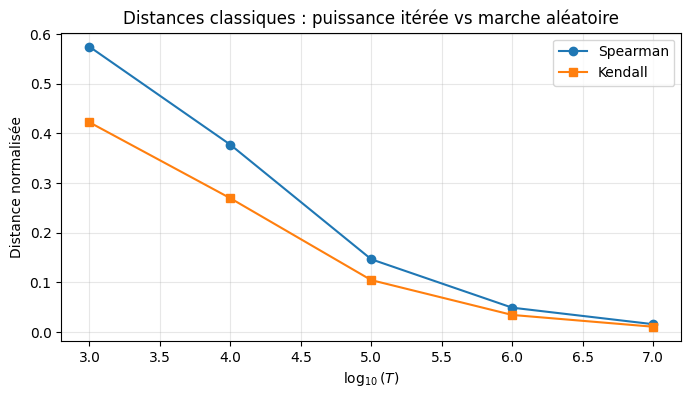

In [17]:
# Évolution des distances classiques en fonction du nombre de pas
ks = list(spearman_dis.keys())
plt.figure(figsize=(8, 4))
plt.plot(ks, [spearman_dis[k] for k in ks], 'o-', label='Spearman')
plt.plot(ks, [kendall_dis[k] for k in ks], 's-', label='Kendall')
plt.xlabel('$\\log_{10}(T)$')
plt.ylabel('Distance normalisée')
plt.title('Distances classiques : puissance itérée vs marche aléatoire')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Precision@k — une métrique dépendante de la profondeur

Les deux métriques précédentes donnent un score **global** sur tout le classement. Or, dans un moteur de recherche, seuls les $k$ premiers résultats comptent (la "première page").

La **Precision@k** mesure la proportion de sommets du top-$k$ de référence qui apparaissent aussi dans le top-$k$ estimé :
$$\text{Precision@k} = \frac{|\text{top-}k(\sigma_1) \cap \text{top-}k(\sigma_2)|}{k}$$

- $1$ = les mêmes $k$ sommets en tête (pas forcément dans le même ordre)
- $0$ = aucun sommet en commun

**Limitation** : la Precision@k ne tient pas compte de l'**ordre** au sein du top-$k$.

In [18]:
def precision_at_k(sigma_true, sigma_est, k):
    """Proportion de sommets en commun dans les top-k des deux classements."""
    return len(set(sigma_true[:k]) & set(sigma_est[:k])) / k

In [19]:
# Precision@k pour différentes valeurs de k et de T
k_values = [5, 10, 20, 50, 100, 200, 500]
prec_data = {}

for T_exp, sigma_k in sigma_s.items():
    prec_data[T_exp] = [precision_at_k(sigma_m, sigma_k, k) for k in k_values]

df_prec = pd.DataFrame(prec_data, index=[f"k={k}" for k in k_values])
df_prec.columns = [f"T=10^{k}" for k in df_prec.columns]
df_prec

,T=10^3,T=10^4,T=10^5,T=10^6,T=10^7
k=5,0.200,0.000,0.40,1.00,1.000
k=10,0.100,0.200,0.60,0.90,0.900
k=20,0.100,0.200,0.70,0.85,1.000
k=50,0.140,0.360,0.74,0.88,0.980
k=100,0.240,0.450,0.77,0.95,0.970
k=200,0.345,0.555,0.81,0.93,0.975
k=500,0.582,0.744,0.91,0.97,0.990


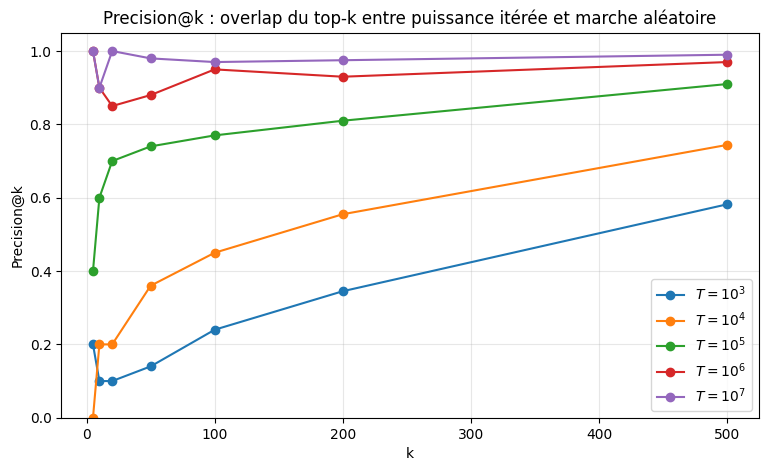

In [20]:
# Plot Precision@k pour chaque T
plt.figure(figsize=(9, 5))
for T_exp, precs in prec_data.items():
    plt.plot(k_values, precs, 'o-', label=f'$T = 10^{T_exp}$')

plt.xlabel('k')
plt.ylabel('Precision@k')
plt.title('Precision@k : overlap du top-k entre puissance itérée et marche aléatoire')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.show()

**Interprétation** : La Precision@k nous montre que même avec peu de pas, la marche aléatoire identifie correctement les sommets les plus importants. Mais cette mesure est binaire (un sommet est dans le top-k ou non) et ne dit rien sur l'ordre.

---

## 9. Distances pondérées — Combiner sensibilité à l'ordre et importance du rang

On veut une métrique qui :
1. Tient compte de **l'ordre** (comme Kendall/Spearman)
2. Accorde **plus de poids** aux éléments en tête de classement (comme Precision@k)

L'idée : pondérer chaque contribution par une fonction décroissante du rang dans le classement de référence.

Trois schémas de pondération :
| Schéma | Poids $w(i)$ | Interprétation |
|---|---|---|
| `inverse` | $1/i$ | Décroissance harmonique |
| `inverse_square` | $1/i^2$ | Forte concentration sur le top |
| `log` | $1/\log_2(i+1)$ | Décroissance douce (inspiré du DCG) |

### 9.1 Distance de Kendall pondérée

On pondère chaque paire $(a, b)$ par le poids de la **meilleure position** de $a$ ou $b$ dans le classement de référence :
$$d_{K,w} = \frac{\sum_{(a,b) \text{ disc.}} w(\min(r_1(a), r_1(b)))}{\sum_{\text{toutes paires}} w(\min(r_1(a), r_1(b)))}$$

Ainsi, une inversion entre les sommets classés 1er et 5ème pèse beaucoup plus qu'entre les 500ème et 505ème.

In [21]:
def weighted_kendall_distance(sigma_true, sigma_est, weight="inverse"):
    """Distance de Kendall pondérée. O(n²)."""
    n = len(sigma_true)
    rank_true = np.empty(n, dtype=int)
    rank_est = np.empty(n, dtype=int)
    rank_true[sigma_true] = np.arange(n)
    rank_est[sigma_est] = np.arange(n)

    concordant = 0.0
    discordant = 0.0

    for a in range(n):
        for b in range(a + 1, n):
            i = min(rank_true[a], rank_true[b]) + 1  # rang 1-indexé

            if weight == "inverse":
                w = 1.0 / i
            elif weight == "inverse_square":
                w = 1.0 / (i ** 2)
            elif weight == "log":
                w = 1.0 / np.log2(i + 1)
            else:
                w = 1.0

            s_true = rank_true[a] - rank_true[b]
            s_est = rank_est[a] - rank_est[b]

            if s_true * s_est > 0:
                concordant += w
            else:
                discordant += w

    tau_w = (concordant - discordant) / (concordant + discordant)
    return (1 - tau_w) / 2

# Vérification : distance avec soi-même = 0
print("Kendall pondéré (inverse) sigma_m vs sigma_m :", weighted_kendall_distance(sigma_m, sigma_m, "inverse"))

Kendall pondéré (inverse) sigma_m vs sigma_m : 0.0


In [22]:
# Calcul pour chaque T et chaque schéma de pondération
# Attention : O(n²) donc potentiellement lent pour n=1000
wk_results = {w: {} for w in ["inverse", "inverse_square", "log"]}

for k, sigma_k in sigma_s.items():
    for w in wk_results:
        wk_results[w][k] = weighted_kendall_distance(sigma_m, sigma_k, weight=w)
    print(f"T = 10^{k} terminé")

print("\nDistance de Kendall pondérée :")
for w, res in wk_results.items():
    print(f"  [{w}]")
    for k, d in res.items():
        print(f"    T = 10^{k} : {d:.6f}")

T = 10^3 terminé
T = 10^4 terminé
T = 10^5 terminé
T = 10^6 terminé
T = 10^7 terminé

Distance de Kendall pondérée :
  [inverse]
    T = 10^3 : 0.303371
    T = 10^4 : 0.163810
    T = 10^5 : 0.032885
    T = 10^6 : 0.009082
    T = 10^7 : 0.002591
  [inverse_square]
    T = 10^3 : 0.144849
    T = 10^4 : 0.116797
    T = 10^5 : 0.003951
    T = 10^6 : 0.001681
    T = 10^7 : 0.000077
  [log]
    T = 10^3 : 0.405409
    T = 10^4 : 0.248823
    T = 10^5 : 0.091159
    T = 10^6 : 0.029201
    T = 10^7 : 0.008972


### 9.2 Distance de Spearman pondérée

Même idée appliquée au Spearman : on pondère le déplacement $|r_1(i) - r_2(i)|$ de chaque sommet $i$ par le poids de sa position dans le classement de référence :
$$d_{S,w} = \frac{\sum_{i=1}^{n} w(r_1(i)) \cdot |r_1(i) - r_2(i)|}{\sum_{i=1}^{n} w(r_1(i)) \cdot |r_1(i) - (n-1-r_1(i))|}$$

Normalisation : le dénominateur est la distance de Spearman pondérée par rapport au classement inversé.

Ainsi :
- $d_{S,w}=0$ pour deux classements identiques
- $d_{S,w}=1$ pour deux classements inversés

Ceci est $O(n)$, donc beaucoup plus rapide que le Kendall pondéré.

In [23]:
def weighted_spearman_distance(sigma1, sigma2, weight="inverse"):
    """Distance de Spearman pondérée, normalisée pour valoir 1 sur l'ordre inversé."""
    n = len(sigma1)
    rank1 = np.argsort(sigma1)  # rank1[v] = position du sommet v dans sigma1
    rank2 = np.argsort(sigma2)

    total = 0.0
    norm = 0.0

    for v in range(n):
        r = rank1[v]
        pos = r + 1  # rang 1-indexé dans le classement de référence

        if weight == "inverse":
            w = 1.0 / pos
        elif weight == "inverse_square":
            w = 1.0 / (pos ** 2)
        elif weight == "log":
            w = 1.0 / np.log2(pos + 1)
        else:
            w = 1.0

        total += w * abs(r - rank2[v])
        # Normalisation: distance vers le classement inversé
        norm += w * abs(r - (n - 1 - r))

    return total / norm if norm > 0 else 0.0

# Vérification
print("Spearman pondéré (inverse) sigma_m vs sigma_m :", weighted_spearman_distance(sigma_m, sigma_m, "inverse"))

Spearman pondéré (inverse) sigma_m vs sigma_m : 0.0


In [24]:
sigma_id = np.arange(6)
sigma_rev = np.arange(5, -1, -1)

print("Spearman pondéré, identiques      :", weighted_spearman_distance(sigma_id, sigma_id))
print("Spearman pondéré, inversés        :", weighted_spearman_distance(sigma_id, sigma_rev))
print("Kendall pondéré, identiques       :", weighted_kendall_distance(sigma_id, sigma_id))
print("Kendall pondéré, inversés         :", weighted_kendall_distance(sigma_id, sigma_rev))

Spearman pondéré, identiques      : 0.0
Spearman pondéré, inversés        : 1.0
Kendall pondéré, identiques       : 0.0
Kendall pondéré, inversés         : 1.0


In [25]:
# Calcul pour chaque T et chaque schéma de pondération
ws_results = {w: {} for w in ["inverse", "inverse_square", "log"]}

for k, sigma_k in sigma_s.items():
    for w in ws_results:
        ws_results[w][k] = weighted_spearman_distance(sigma_m, sigma_k, weight=w)

print("Distance de Spearman pondérée :")
for w, res in ws_results.items():
    print(f"  [{w}]")
    for k, d in res.items():
        print(f"    T = 10^{k} : {d:.6f}")

Distance de Spearman pondérée :
  [inverse]
    T = 10^3 : 0.327840
    T = 10^4 : 0.183968
    T = 10^5 : 0.041998
    T = 10^6 : 0.013152
    T = 10^7 : 0.004054
  [inverse_square]
    T = 10^3 : 0.144529
    T = 10^4 : 0.116684
    T = 10^5 : 0.004117
    T = 10^6 : 0.002030
    T = 10^7 : 0.000118
  [log]
    T = 10^3 : 0.537315
    T = 10^4 : 0.344891
    T = 10^5 : 0.130201
    T = 10^6 : 0.043193
    T = 10^7 : 0.013857


**Interprétation** : Les distances pondérées sont plus sensibles à la qualité du classement en tête. Avec la pondération `inverse_square`, seul le top ~30 sommets compte vraiment. On observe que même avec peu de pas, les sommets les plus importants sont généralement bien identifiés.

## 10. Tableau récapitulatif

Synthèse de toutes les métriques pour chaque nombre de pas de la marche aléatoire.

In [26]:
# Tableau récapitulatif
ks = sorted(sigma_s.keys())
summary = pd.DataFrame(index=[f"$10^{k}$" for k in ks])
summary.index.name = "T (pas)"

summary["Spearman"] = [spearman_dis[k] for k in ks]
summary["Kendall"] = [kendall_dis[k] for k in ks]
summary["P@10"] = [precision_at_k(sigma_m, sigma_s[k], 10) for k in ks]
summary["P@50"] = [precision_at_k(sigma_m, sigma_s[k], 50) for k in ks]

for w in ["inverse", "inverse_square", "log"]:
    summary[f"wKendall ({w})"] = [wk_results[w][k] for k in ks]
    summary[f"wSpearman ({w})"] = [ws_results[w][k] for k in ks]

summary.round(6)

,Spearman,Kendall,P@10,P@50,wKendall (inverse),wSpearman (inverse),wKendall (inverse_square),wSpearman (inverse_square),wKendall (log),wSpearman (log)
T (pas),,,,,,,,,,
$10^3$,0.574416,0.422166,0.1,0.14,0.303371,0.327840,0.144849,0.144529,0.405409,0.537315
$10^4$,0.377072,0.269263,0.2,0.36,0.163810,0.183968,0.116797,0.116684,0.248823,0.344891
$10^5$,0.146388,0.104418,0.6,0.74,0.032885,0.041998,0.003951,0.004117,0.091159,0.130201
$10^6$,0.048920,0.034270,0.9,0.88,0.009082,0.013152,0.001681,0.002030,0.029201,0.043193
$10^7$,0.015668,0.010559,0.9,0.98,0.002591,0.004054,0.000077,0.000118,0.008972,0.013857


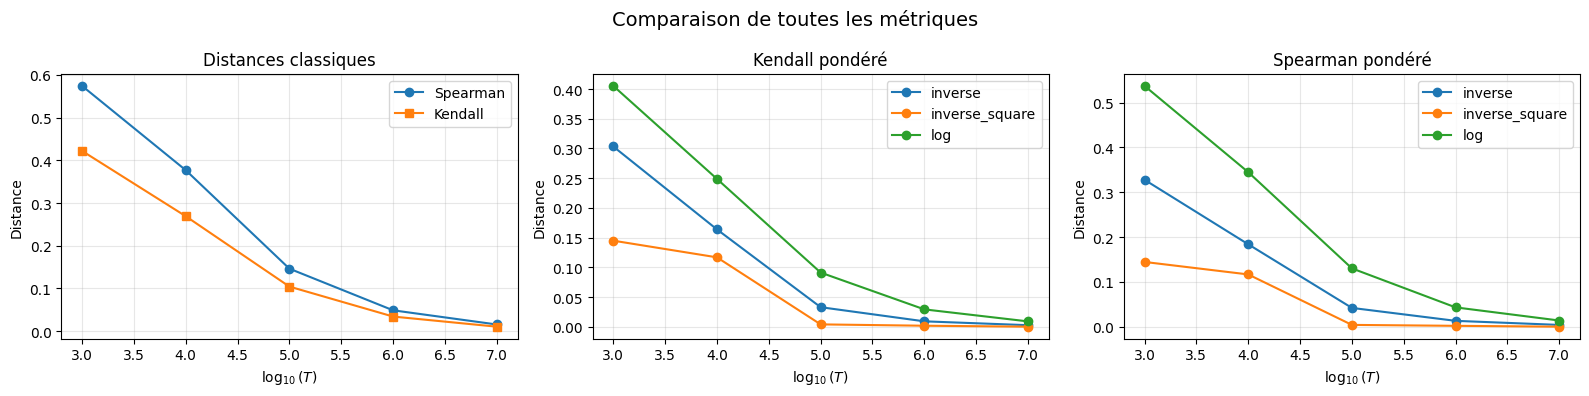

In [27]:
# Visualisation comparative
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Distances classiques
axes[0].plot(ks, [spearman_dis[k] for k in ks], 'o-', label='Spearman')
axes[0].plot(ks, [kendall_dis[k] for k in ks], 's-', label='Kendall')
axes[0].set_xlabel('$\\log_{10}(T)$')
axes[0].set_ylabel('Distance')
axes[0].set_title('Distances classiques')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Kendall pondéré
for w in ["inverse", "inverse_square", "log"]:
    axes[1].plot(ks, [wk_results[w][k] for k in ks], 'o-', label=w)
axes[1].set_xlabel('$\\log_{10}(T)$')
axes[1].set_ylabel('Distance')
axes[1].set_title('Kendall pondéré')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Spearman pondéré
for w in ["inverse", "inverse_square", "log"]:
    axes[2].plot(ks, [ws_results[w][k] for k in ks], 'o-', label=w)
axes[2].set_xlabel('$\\log_{10}(T)$')
axes[2].set_ylabel('Distance')
axes[2].set_title('Spearman pondéré')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Comparaison de toutes les métriques', fontsize=14)
plt.tight_layout()
plt.show()

---

# Partie III — Application à un graphe réel

On applique notre pipeline PageRank à un **vrai réseau** pour valider l'approche sur des données réalistes.

On utilise le jeu de données **wiki-Vote** de SNAP (Stanford Network Analysis Project) :
- ~7K nœuds (utilisateurs Wikipedia)
- ~100K arêtes orientées (votes pour l'élection d'administrateur)

Ensuite, on compare l'estimation par puissance itérée (implémentation sparse) avec la marche aléatoire.

In [28]:
import urllib.request
import gzip
import os
import networkx as nx
from scipy import sparse

In [29]:
# Téléchargement du jeu de données wiki-Vote
url = "https://snap.stanford.edu/data/wiki-Vote.txt.gz"
gz_path = "data/wiki-Vote.txt.gz"
txt_path = "data/wiki-Vote.txt"

if not os.path.exists(txt_path):
    print("Téléchargement...")
    urllib.request.urlretrieve(url, gz_path)
    with gzip.open(gz_path, 'rb') as f_in:
        with open(txt_path, 'wb') as f_out:
            f_out.write(f_in.read())
    print("Téléchargement terminé.")
else:
    print("Fichier déjà présent.")

# Chargement dans un graphe orienté NetworkX
G_real = nx.read_edgelist(txt_path, comments='#', create_using=nx.DiGraph(), nodetype=int)
print(f"Graphe wiki-Vote : {G_real.number_of_nodes()} nœuds, {G_real.number_of_edges()} arêtes")

Fichier déjà présent.
Graphe wiki-Vote : 7115 nœuds, 103689 arêtes


### PageRank par puissance itérée (version sparse)

Pour les grands graphes, on ne peut plus stocker une matrice $n \times n$ dense.
On utilise une matrice **sparse** pour la partie navigation $G$, et on traite la téléportation de manière vectorielle sans la stocker explicitement :

$$\pi^{(t+1)} = \alpha \, G^T \pi^{(t)} + \alpha \, d^T \pi^{(t)} \cdot \frac{\mathbf{1}}{n} + (1 - \alpha) \, \frac{\mathbf{1}}{n}$$

Où $d$ est le vecteur indicateur des nœuds puits (sans lien sortant).

In [30]:
def sparse_pagerank(G_nx, alpha=0.85, tol=1e-9, max_iter=500):
    """PageRank par puissance itérée sur un graphe NetworkX, en sparse."""
    nodes = sorted(G_nx.nodes())
    node_to_idx = {v: i for i, v in enumerate(nodes)}
    n = len(nodes)

    # Construction de la matrice d'adjacence sparse
    rows, cols, data = [], [], []
    out_degree = np.zeros(n)

    for u, v in G_nx.edges():
        i, j = node_to_idx[u], node_to_idx[v]
        rows.append(i)
        cols.append(j)
        data.append(1.0)
        out_degree[i] += 1

    A_sp = sparse.csr_matrix((data, (rows, cols)), shape=(n, n))

    # Normalisation par ligne (matrice de navigation G)
    dangling = (out_degree == 0)
    out_degree[dangling] = 1  # éviter division par 0
    D_inv = sparse.diags(1.0 / out_degree)
    G_sp = D_inv @ A_sp  # G[i,j] = A[i,j] / deg+(i)

    # Puissance itérée
    pi = np.ones(n) / n
    distances = []

    for it in range(max_iter):
        # pi_new = alpha * G^T @ pi + alpha * (dangling^T @ pi) * (1/n) + (1-alpha) * (1/n)
        pi_new = alpha * G_sp.T.dot(pi)
        dangling_mass = alpha * pi[dangling].sum()
        pi_new += (dangling_mass + (1 - alpha)) / n

        d = np.abs(pi_new - pi).sum()
        distances.append(d)
        if d < tol:
            break
        pi = pi_new

    return pi_new, nodes, node_to_idx, distances

pi_real, nodes_real, node_to_idx_real, dist_real = sparse_pagerank(G_real, alpha=0.85)
n_real = len(nodes_real)
print(f"Convergence en {len(dist_real)} itérations")
print(f"Top 10 nœuds (PageRank puissance itérée) :")
top10_idx = np.argsort(pi_real)[::-1][:10]
for rank, idx in enumerate(top10_idx):
    print(f"  {rank+1}. nœud {nodes_real[idx]} — pi = {pi_real[idx]:.6f}")

Convergence en 26 itérations
Top 10 nœuds (PageRank puissance itérée) :
  1. nœud 4037 — pi = 0.004607
  2. nœud 15 — pi = 0.003680
  3. nœud 6634 — pi = 0.003587
  4. nœud 2625 — pi = 0.003284
  5. nœud 2398 — pi = 0.002609
  6. nœud 2470 — pi = 0.002524
  7. nœud 2237 — pi = 0.002497
  8. nœud 4191 — pi = 0.002268
  9. nœud 7553 — pi = 0.002170
  10. nœud 5254 — pi = 0.002150


In [31]:
# Validation avec NetworkX
pr_nx = nx.pagerank(G_real, alpha=0.85, tol=1e-9)
pi_nx = np.array([pr_nx[v] for v in nodes_real])

erreur_nx = np.abs(pi_real - pi_nx).max()
print(f"Erreur max entre notre implémentation sparse et NetworkX : {erreur_nx:.2e}")

Erreur max entre notre implémentation sparse et NetworkX : 3.29e-07


### Marche aléatoire sur le graphe réel (version sparse)

On réutilise l'approche CDF + `searchsorted`, mais sur la matrice sparse.
Pour chaque nœud, on pré-calcule les voisins sortants et la CDF locale.

In [32]:
def sparse_random_walk_pagerank(G_nx, nodes, node_to_idx, alpha=0.85, nb_pas=10**6, seed=42):
    """Estimation du PageRank par marche aléatoire sur un graphe NetworkX."""
    np.random.seed(seed)
    n = len(nodes)

    # Pré-calcul des voisins sortants de chaque nœud
    neighbors = {}
    for v in nodes:
        succ = list(G_nx.successors(v))
        neighbors[node_to_idx[v]] = [node_to_idx[u] for u in succ]

    count = np.zeros(n)
    pos = np.random.randint(n)
    count[pos] += 1

    for _ in range(nb_pas - 1):
        if np.random.rand() < alpha and len(neighbors[pos]) > 0:
            # Suivre un lien sortant uniformément
            pos = neighbors[pos][np.random.randint(len(neighbors[pos]))]
        else:
            # Téléportation uniforme
            pos = np.random.randint(n)
        count[pos] += 1

    return count / nb_pas

# Estimation avec différents nombres de pas
pi_rw_real = {}
for k in [4, 5, 6, 7]:
    pi_rw_real[k] = sparse_random_walk_pagerank(G_real, nodes_real, node_to_idx_real,
                                                  alpha=0.85, nb_pas=10**k, seed=42)
    err = np.mean(np.abs(pi_rw_real[k] - pi_real))
    print(f"T = 10^{k} : erreur moyenne = {err:.6f}")

T = 10^4 : erreur moyenne = 0.000084
T = 10^5 : erreur moyenne = 0.000026
T = 10^6 : erreur moyenne = 0.000008
T = 10^7 : erreur moyenne = 0.000003


### Comparaison des classements sur le graphe réel

In [33]:
# Classements
sigma_real_m = np.flip(np.argsort(pi_real))
sigma_real_s = {k: np.flip(np.argsort(pi_k)) for k, pi_k in pi_rw_real.items()}

# Distances classiques
spearman_real = {k: spearman_distance(sigma_real_m, s) for k, s in sigma_real_s.items()}
kendall_real = {k: kendall_distance(sigma_real_m, s) for k, s in sigma_real_s.items()}

# Precision@k
prec_real = {}
for kk in [10, 50, 100]:
    prec_real[kk] = {k: precision_at_k(sigma_real_m, s, kk) for k, s in sigma_real_s.items()}

# Spearman pondéré (O(n), rapide même pour n=7000)
ws_real = {w: {} for w in ["inverse", "inverse_square", "log"]}
for k, s in sigma_real_s.items():
    for w in ws_real:
        ws_real[w][k] = weighted_spearman_distance(sigma_real_m, s, weight=w)

print("Distances classiques sur wiki-Vote :")
for k in sorted(sigma_real_s.keys()):
    print(f"  T=10^{k} : Spearman={spearman_real[k]:.4f}, Kendall={kendall_real[k]:.4f}, "
          f"P@10={prec_real[10][k]:.2f}, P@50={prec_real[50][k]:.2f}, P@100={prec_real[100][k]:.2f}")

print("\nSpearman pondéré :")
for w in ws_real:
    print(f"  [{w}]")
    for k in sorted(sigma_real_s.keys()):
        print(f"    T=10^{k} : {ws_real[w][k]:.6f}")

Distances classiques sur wiki-Vote :
  T=10^4 : Spearman=0.3769, Kendall=0.3024, P@10=0.70, P@50=0.68, P@100=0.76
  T=10^5 : Spearman=0.3444, Kendall=0.2579, P@10=0.90, P@50=0.86, P@100=0.90
  T=10^6 : Spearman=0.3114, Kendall=0.2315, P@10=1.00, P@50=0.98, P@100=0.97
  T=10^7 : Spearman=0.3009, Kendall=0.2268, P@10=1.00, P@50=0.98, P@100=0.99

Spearman pondéré :
  [inverse]
    T=10^4 : 0.067861
    T=10^5 : 0.042833
    T=10^6 : 0.034431
    T=10^7 : 0.032159
  [inverse_square]
    T=10^4 : 0.000584
    T=10^5 : 0.000170
    T=10^6 : 0.000076
    T=10^7 : 0.000057
  [log]
    T=10^4 : 0.344846
    T=10^5 : 0.305585
    T=10^6 : 0.273840
    T=10^7 : 0.264026


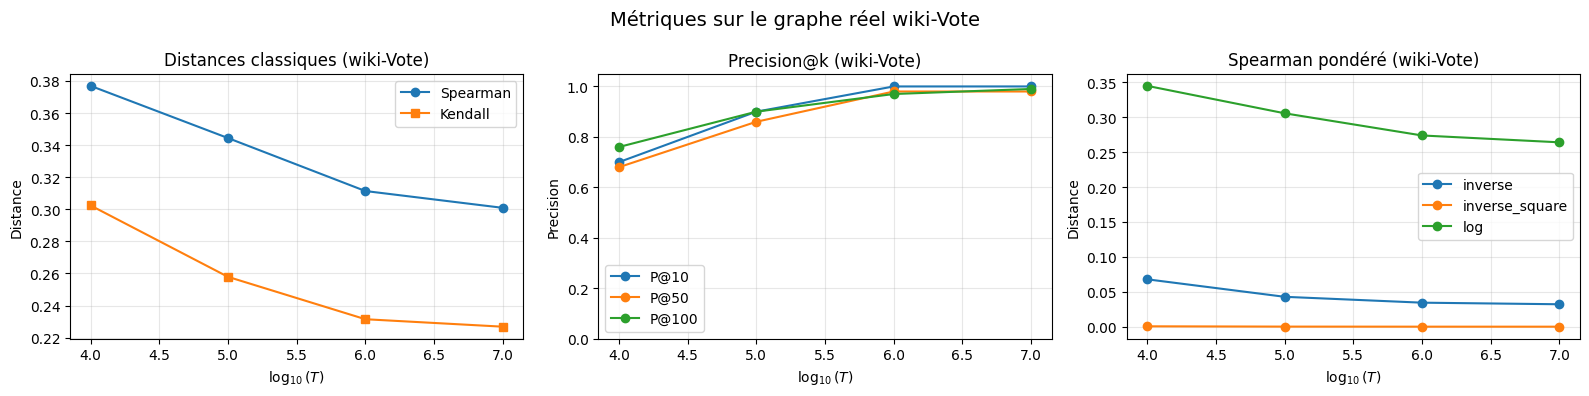

In [34]:
# Visualisation des résultats sur le graphe réel
ks_real = sorted(sigma_real_s.keys())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distances classiques
axes[0].plot(ks_real, [spearman_real[k] for k in ks_real], 'o-', label='Spearman')
axes[0].plot(ks_real, [kendall_real[k] for k in ks_real], 's-', label='Kendall')
axes[0].set_xlabel('$\\log_{10}(T)$')
axes[0].set_ylabel('Distance')
axes[0].set_title('Distances classiques (wiki-Vote)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision@k
for kk in [10, 50, 100]:
    axes[1].plot(ks_real, [prec_real[kk][k] for k in ks_real], 'o-', label=f'P@{kk}')
axes[1].set_xlabel('$\\log_{10}(T)$')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision@k (wiki-Vote)')
axes[1].legend()
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3)

# Spearman pondéré
for w in ["inverse", "inverse_square", "log"]:
    axes[2].plot(ks_real, [ws_real[w][k] for k in ks_real], 'o-', label=w)
axes[2].set_xlabel('$\\log_{10}(T)$')
axes[2].set_ylabel('Distance')
axes[2].set_title('Spearman pondéré (wiki-Vote)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Métriques sur le graphe réel wiki-Vote', fontsize=14)
plt.tight_layout()
plt.show()

### Application à un graphe de citations arXiv

On applique le même pipeline au réseau de **citations Cit-HepTh** (physique théorique des hautes énergies) :
- ~27K articles
- ~352K citations
- Une arête $(u, v)$ signifie que l'article $u$ cite l'article $v$

In [35]:
# Téléchargement du jeu de données Cit-HepTh
url_cit = "https://snap.stanford.edu/data/cit-HepTh.txt.gz"
gz_path_cit = "data/cit-HepTh.txt.gz"
txt_path_cit = "data/cit-HepTh.txt"

if not os.path.exists(txt_path_cit):
    print("Téléchargement...")
    urllib.request.urlretrieve(url_cit, gz_path_cit)
    with gzip.open(gz_path_cit, 'rb') as f_in:
        with open(txt_path_cit, 'wb') as f_out:
            f_out.write(f_in.read())
    print("Téléchargement terminé.")
else:
    print("Fichier déjà présent.")

G_cit = nx.read_edgelist(txt_path_cit, comments='#', create_using=nx.DiGraph(), nodetype=int)
print(f"Graphe Cit-HepTh : {G_cit.number_of_nodes()} nœuds, {G_cit.number_of_edges()} arêtes")

Fichier déjà présent.
Graphe Cit-HepTh : 27770 nœuds, 352807 arêtes


In [36]:
# PageRank par puissance itérée sparse
pi_cit, nodes_cit, node_to_idx_cit, dist_cit = sparse_pagerank(G_cit, alpha=0.85)
n_cit = len(nodes_cit)
print(f"Convergence en {len(dist_cit)} itérations")

print(f"\nTop 10 articles les plus influents (par PageRank) :")
top10_cit = np.argsort(pi_cit)[::-1][:10]
for rank, idx in enumerate(top10_cit):
    print(f"  {rank+1}. article {nodes_cit[idx]} — pi = {pi_cit[idx]:.6f}")

Convergence en 95 itérations

Top 10 articles les plus influents (par PageRank) :
  1. article 9207016 — pi = 0.006229
  2. article 9407087 — pi = 0.006084
  3. article 9201015 — pi = 0.005638
  4. article 9503124 — pi = 0.004469
  5. article 9510017 — pi = 0.004210
  6. article 9402044 — pi = 0.003821
  7. article 9711200 — pi = 0.003368
  8. article 9410167 — pi = 0.003290
  9. article 9408099 — pi = 0.003124
  10. article 9402002 — pi = 0.002895


In [37]:
# Marche aléatoire sur le graphe de citations
pi_rw_cit = {}
for k in [5, 6, 7]:
    pi_rw_cit[k] = sparse_random_walk_pagerank(G_cit, nodes_cit, node_to_idx_cit,
                                                 alpha=0.85, nb_pas=10**k, seed=42)
    err = np.mean(np.abs(pi_rw_cit[k] - pi_cit))
    print(f"T = 10^{k} : erreur moyenne = {err:.6f}")

T = 10^5 : erreur moyenne = 0.000013
T = 10^6 : erreur moyenne = 0.000004
T = 10^7 : erreur moyenne = 0.000001


In [38]:
# Métriques sur le graphe de citations
sigma_cit_m = np.flip(np.argsort(pi_cit))
sigma_cit_s = {k: np.flip(np.argsort(pk)) for k, pk in pi_rw_cit.items()}

print("=== Graphe de citations Cit-HepTh ===")
print(f"{'T':>10} | {'Spearman':>10} | {'Kendall':>10} | {'P@10':>6} | {'P@50':>6} | {'wSpearman (inv)':>16}")
print("-" * 75)
for k in sorted(sigma_cit_s.keys()):
    s = spearman_distance(sigma_cit_m, sigma_cit_s[k])
    kd = kendall_distance(sigma_cit_m, sigma_cit_s[k])
    p10 = precision_at_k(sigma_cit_m, sigma_cit_s[k], 10)
    p50 = precision_at_k(sigma_cit_m, sigma_cit_s[k], 50)
    ws = weighted_spearman_distance(sigma_cit_m, sigma_cit_s[k], weight="inverse")
    print(f"{'10^'+str(k):>10} | {s:>10.6f} | {kd:>10.6f} | {p10:>6.2f} | {p50:>6.2f} | {ws:>16.6f}")

=== Graphe de citations Cit-HepTh ===
         T |   Spearman |    Kendall |   P@10 |   P@50 |  wSpearman (inv)
---------------------------------------------------------------------------
      10^5 |   0.384947 |   0.283139 |   0.90 |   0.96 |         0.052210
      10^6 |   0.213691 |   0.153794 |   1.00 |   0.98 |         0.022329
      10^7 |   0.097624 |   0.069833 |   1.00 |   1.00 |         0.008885


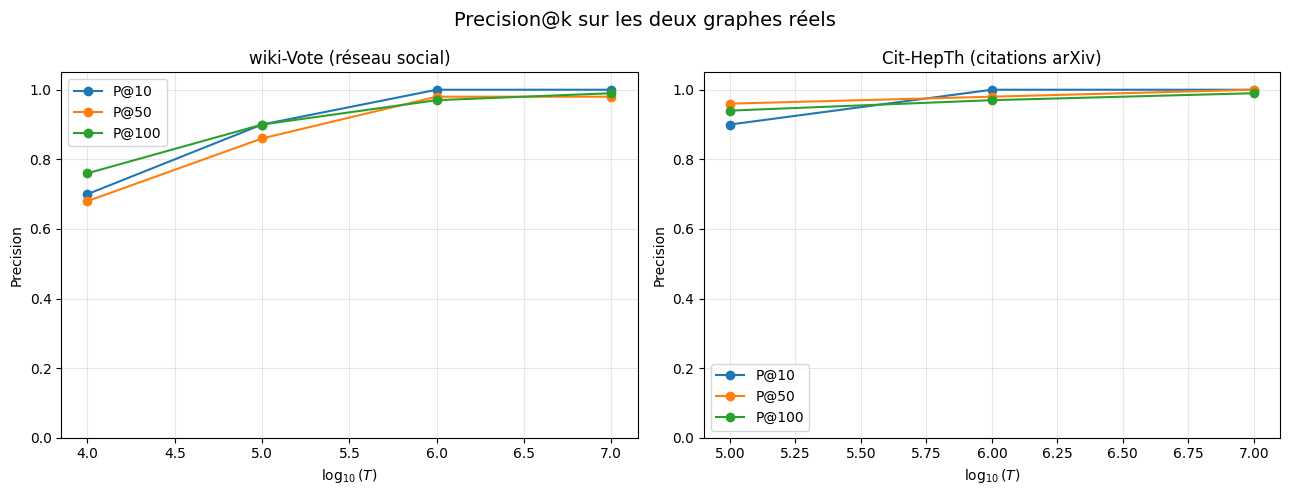

In [39]:
# Comparaison visuelle des top sommets sur les deux graphes réels
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# wiki-Vote
for kk in [10, 50, 100]:
    axes[0].plot(ks_real, [prec_real[kk][k] for k in ks_real], 'o-', label=f'P@{kk}')
axes[0].set_xlabel('$\\log_{10}(T)$')
axes[0].set_ylabel('Precision')
axes[0].set_title('wiki-Vote (réseau social)')
axes[0].legend()
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)

# Cit-HepTh
ks_cit = sorted(sigma_cit_s.keys())
for kk in [10, 50, 100]:
    vals = [precision_at_k(sigma_cit_m, sigma_cit_s[k], kk) for k in ks_cit]
    axes[1].plot(ks_cit, vals, 'o-', label=f'P@{kk}')
axes[1].set_xlabel('$\\log_{10}(T)$')
axes[1].set_ylabel('Precision')
axes[1].set_title('Cit-HepTh (citations arXiv)')
axes[1].legend()
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Precision@k sur les deux graphes réels', fontsize=14)
plt.tight_layout()
plt.show()

## Conclusion

- La **puissance itérée** converge géométriquement (taux $\alpha$) et donne le PageRank exact.
- La **marche aléatoire** converge en $O(1/\sqrt{T})$ mais ne nécessite pas de stocker la matrice.
- Les métriques **classiques** (Spearman, Kendall) traitent tous les sommets de manière égale.
- La **Precision@k** se concentre sur le top-$k$ mais ignore l'ordre.
- Les **distances pondérées** (Kendall pondéré, Spearman pondéré) combinent les deux aspects : sensibilité à l'ordre **et** importance du rang.
- Sur les graphes réels (wiki-Vote, Cit-HepTh), les mêmes tendances se confirment : avec suffisamment de pas, la marche aléatoire identifie correctement les nœuds les plus importants.

## Export des résultats en CSV

Cette section construit deux DataFrames avec toutes les métriques calculées pour chaque nombre de pas :
- graphe aléatoire
- graphe réel wiki-Vote

Puis elle les exporte dans le dossier `data/`.

In [40]:
import os

# Dossier de sortie
os.makedirs("resultats", exist_ok=True)

# ============================
# 1) Graphe aléatoire
# ============================
rows_random = []
for k in sorted(sigma_s.keys()):
    row = {
        "graph": "random",
        "log10_T": k,
        "T": 10**k,
        "spearman": spearman_dis.get(k, np.nan),
        "kendall": kendall_dis.get(k, np.nan),
        "precision_at_10": precision_at_k(sigma_m, sigma_s[k], 10),
        "precision_at_50": precision_at_k(sigma_m, sigma_s[k], 50),
        "precision_at_100": precision_at_k(sigma_m, sigma_s[k], 100),
        "weighted_kendall_inverse": wk_results.get("inverse", {}).get(k, np.nan),
        "weighted_kendall_inverse_square": wk_results.get("inverse_square", {}).get(k, np.nan),
        "weighted_kendall_log": wk_results.get("log", {}).get(k, np.nan),
        "weighted_spearman_inverse": ws_results.get("inverse", {}).get(k, np.nan),
        "weighted_spearman_inverse_square": ws_results.get("inverse_square", {}).get(k, np.nan),
        "weighted_spearman_log": ws_results.get("log", {}).get(k, np.nan),
    }
    rows_random.append(row)

df_metrics_random = pd.DataFrame(rows_random)

# ============================
# 2) Graphe wiki-Vote
# ============================
rows_wikivote = []
available_precisions = sorted(prec_real.keys()) if "prec_real" in globals() else []

for k in sorted(sigma_real_s.keys()):
    row = {
        "graph": "wiki_vote",
        "log10_T": k,
        "T": 10**k,
        "spearman": spearman_real.get(k, np.nan),
        "kendall": kendall_real.get(k, np.nan),
        "weighted_spearman_inverse": ws_real.get("inverse", {}).get(k, np.nan),
        "weighted_spearman_inverse_square": ws_real.get("inverse_square", {}).get(k, np.nan),
        "weighted_spearman_log": ws_real.get("log", {}).get(k, np.nan),
    }

    # Ajout dynamique des Precision@k disponibles (ex: 10, 50, 100)
    for kk in available_precisions:
        row[f"precision_at_{kk}"] = prec_real[kk].get(k, np.nan)

    rows_wikivote.append(row)

df_metrics_wikivote = pd.DataFrame(rows_wikivote)

# ============================
# Exports CSV
# ============================
path_random = "resultats/resultats_distances_graphe_aleatoire.csv"
path_wikivote = "resultats/resultats_distances_wikivote.csv"

df_metrics_random.to_csv(path_random, index=False)
df_metrics_wikivote.to_csv(path_wikivote, index=False)

print("Exports réalisés :")
print(f"- {path_random} ({len(df_metrics_random)} lignes)")
print(f"- {path_wikivote} ({len(df_metrics_wikivote)} lignes)")

print("\nAperçu graphe aléatoire :")
display(df_metrics_random)

print("\nAperçu wiki-Vote :")
display(df_metrics_wikivote)

Exports réalisés :
- resultats/resultats_distances_graphe_aleatoire.csv (5 lignes)
- resultats/resultats_distances_wikivote.csv (4 lignes)

Aperçu graphe aléatoire :


,graph,log10_T,T,spearman,kendall,precision_at_10,precision_at_50,precision_at_100,weighted_kendall_inverse,weighted_kendall_inverse_square,weighted_kendall_log,weighted_spearman_inverse,weighted_spearman_inverse_square,weighted_spearman_log
0,random,3,1000,0.574416,0.422166,0.1,0.14,0.24,0.303371,0.144849,0.405409,0.327840,0.144529,0.537315
1,random,4,10000,0.377072,0.269263,0.2,0.36,0.45,0.163810,0.116797,0.248823,0.183968,0.116684,0.344891
2,random,5,100000,0.146388,0.104418,0.6,0.74,0.77,0.032885,0.003951,0.091159,0.041998,0.004117,0.130201
3,random,6,1000000,0.048920,0.034270,0.9,0.88,0.95,0.009082,0.001681,0.029201,0.013152,0.002030,0.043193
4,random,7,10000000,0.015668,0.010559,0.9,0.98,0.97,0.002591,0.000077,0.008972,0.004054,0.000118,0.013857



Aperçu wiki-Vote :


,graph,log10_T,T,spearman,kendall,weighted_spearman_inverse,weighted_spearman_inverse_square,weighted_spearman_log,precision_at_10,precision_at_50,precision_at_100
0,wiki_vote,4,10000,0.376931,0.302379,0.067861,0.000584,0.344846,0.7,0.68,0.76
1,wiki_vote,5,100000,0.344404,0.257891,0.042833,0.000170,0.305585,0.9,0.86,0.90
2,wiki_vote,6,1000000,0.311390,0.231484,0.034431,0.000076,0.273840,1.0,0.98,0.97
3,wiki_vote,7,10000000,0.300912,0.226836,0.032159,0.000057,0.264026,1.0,0.98,0.99
